# *Breast Cancer Detection Using Deep Learning (Fuzzy)*

# 01 - Data Exploration

Purpose:
- Load raw breast thermogram images
- Visualize sample images
- Inspect image size, channels and intensity range
- Verify dataset structure

Dataset(s):
- DMR-IR

In [1]:
import cv2
import sys, os
import numpy as np

In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.utils import section

## STAGE 1: PRE-PROCESSING

In [4]:
from src.preprocessing import StorageConfig, run_preprocessing
from src.utils import PRE_CFG, SCH_CFG, base_path, dmr_ir_o, load_preprocessing_results, preprocessed_results_path

In [5]:
DMR_IR_PATH = base_path + dmr_ir_o

image_files = sorted([
    f for f in os.listdir(DMR_IR_PATH)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])
print(f'Found {len(image_files)} images:')
for i, f in enumerate(image_files):
    print(f'  [{i}] {f}')

Found 17 images:
  [0] TFRON_V11_31-10-2012_0.jpg
  [1] TFRON_V12_31-10-2012_0.jpg
  [2] TFRON_V13_31-10-2012_0.jpg
  [3] TFRON_V15_31-10-2012_0.jpg
  [4] TFRON_V16_31-10-2012_0.jpg
  [5] TFRON_V1_26-10-2012_0.jpg
  [6] TFRON_V243_12-3-2014_0.jpg
  [7] TFRON_V247_21-5-2014_0.jpg
  [8] TFRON_V2_30-10-2012_0.jpg
  [9] TFRON_V39_7-11-2012_0.jpg
  [10] TFRON_V4_30-10-2012_0.jpg
  [11] TFRON_V59_20-11-2012_0.jpg
  [12] TFRON_V5_30-10-2012_0.jpg
  [13] TFRON_V6_30-10-2012_0.jpg
  [14] TFRON_V7_31-10-2012_0.jpg
  [15] TFRON_V8_31-10-2012_0.jpg
  [16] TFRON_V9_31-10-2012_0.jpg


In [6]:
IMAGE_INDEX = 6   # ← change this to try a different image
IMAGE_PATH  = os.path.join(DMR_IR_PATH, image_files[IMAGE_INDEX])

  PRE-PROCESSING: TFRON_V243_12-3-2014_0.jpg
[1.0] Loaded 480×640.
[1.1] FLIR overlay zeroed: top 38px.
[1.2] No colour bar detected.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size

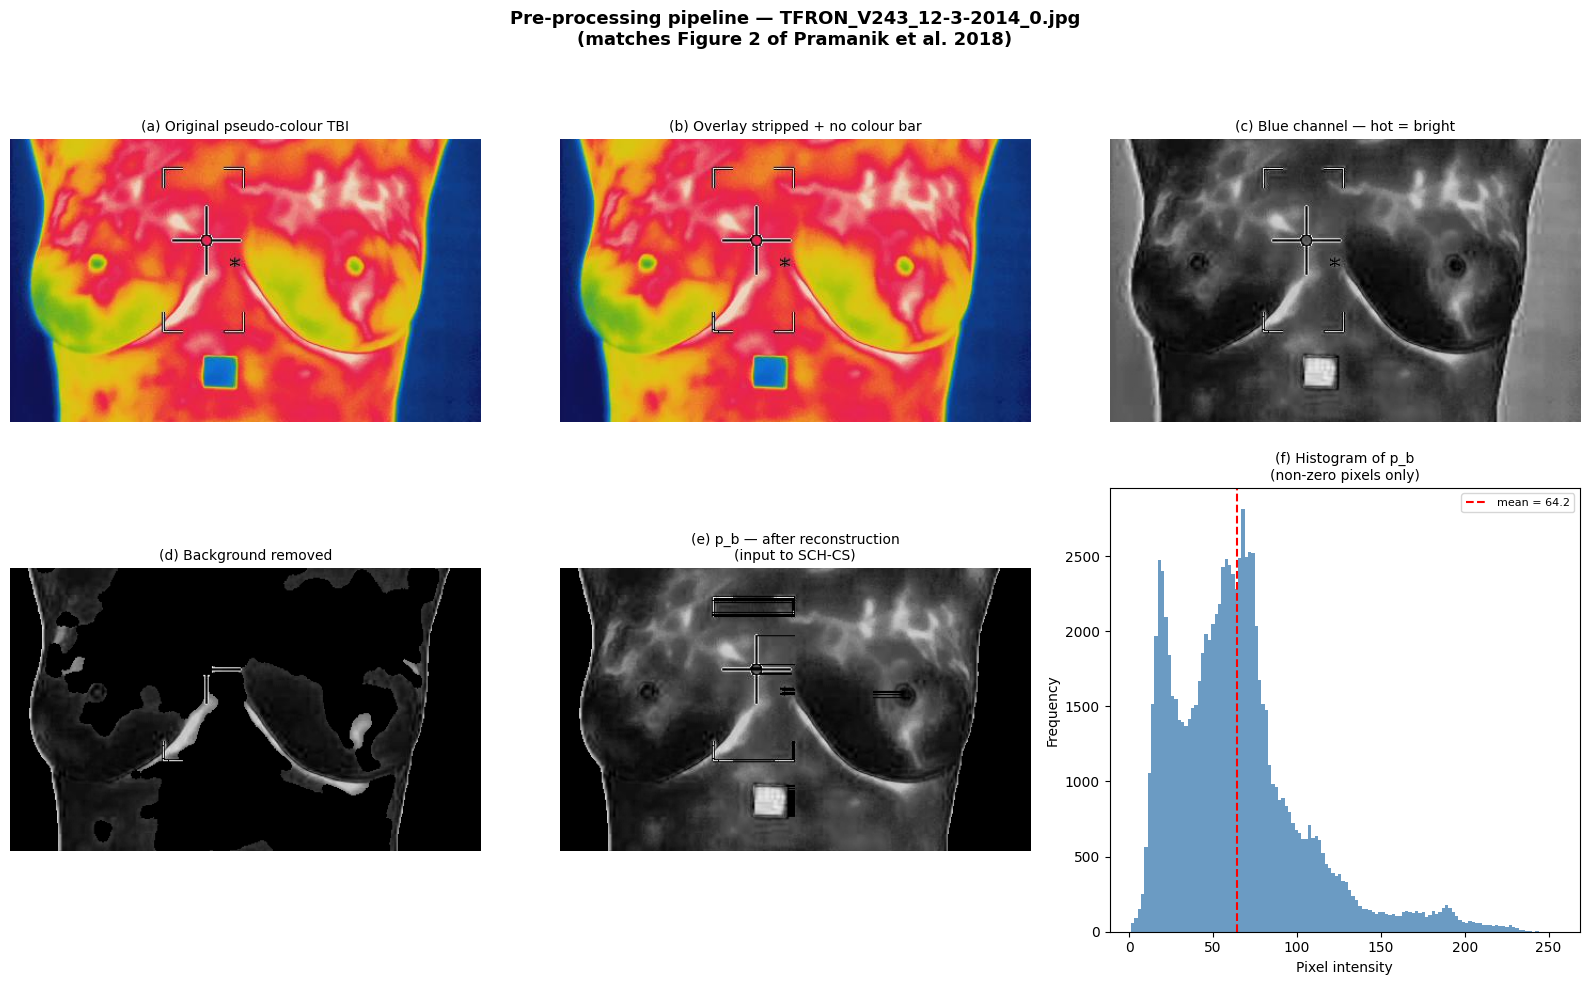

[Save] p_b saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706\TFRON_V243_12-3-2014_0_pb.png
[Save] Grayscale saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706\TFRON_V243_12-3-2014_0_grayscale.png
[Save] Background removed saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706\TFRON_V243_12-3-2014_0_bg_removed.png
[Save] Original color saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706\TFRON_V243_12-3-2014_0_original_color.png
[Save] Metadata saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706\TFRON_V243_12-3-2014_0_metadata.json

Results saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706
p_b saved at: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260414_225706\TFRON_V243_12-3-2014_0_pb.png


In [7]:
preprocessing_results = run_preprocessing(
    image_path=IMAGE_PATH,
    cfg=PRE_CFG,
    visualize=True,
    save_results=True,
    storage_config=StorageConfig(output_dir=preprocessed_results_path)
)

# PREPROCESSING RESULTS
print(f"\nResults saved to: {preprocessing_results['run_dir']}")
print(f"p_b saved at: {preprocessing_results['saved_paths']['pb']}")

In [8]:
# lOADING PRE-PROCESSING RESULTS FOR NEXT STEPS:
preprocessing_results_loaded = load_preprocessing_results(preprocessing_results['run_dir'])
pb = preprocessing_results_loaded['pb']
image_name = preprocessing_results_loaded['base_name']
print(image_name)

[Load] Loaded preprocessing results for: TFRON_V243_12-3-2014_0
pb shape: (265, 441)
TFRON_V243_12-3-2014_0


## STAGE 1: SCH-CS

In [9]:
from src.sch_cs import run_schcs, SchCsStorageConfig
from src.utils import schcs_results_path, load_schcs_results


  SCH-CS: TFRON_V243_12-3-2014_0

[SCH 2.1] Building histogram...
  N=92605, R=242, m=N/R=382.67, peaks found=70

[SCH 2.2] Computing rho...
  r=28, V=939.3, C=98.6, max_h=1455 at level 73
  rho=-367.91 (fallback to m) → rho_eff=382.67

[SCH 2.3] Computing t*...
  |A|=42, A range=[98,243], m(A)=169.40, alpha(A)=42.81, t*=126.60

[SCH 2.4] Computing th...
  m(p)=64.19, t*=126.60 → th = t* = 126.60

[SCH 2.5] Thresholding (th=126.60) and labelling...
  SR pixels=6207, regions total=81, after size filter=26

[CS 2.7] Weighted centroids for 26 regions...
  R(   1): centroid=(132.7,30.4), size=500px
  R(   7): centroid=(29.1,402.1), size=20px
  R(   8): centroid=(52.5,330.2), size=1058px
  R(   9): centroid=(27.1,151.1), size=21px
  R(  11): centroid=(54.8,280.3), size=759px
  R(  13): centroid=(45.4,117.7), size=204px
  R(  14): centroid=(46.2,364.3), size=96px
  R(  21): centroid=(48.0,227.7), size=38px
  R(  24): centroid=(55.4,86.5), size=39px
  R(  29): centroid=(64.8,45.2), size=41px

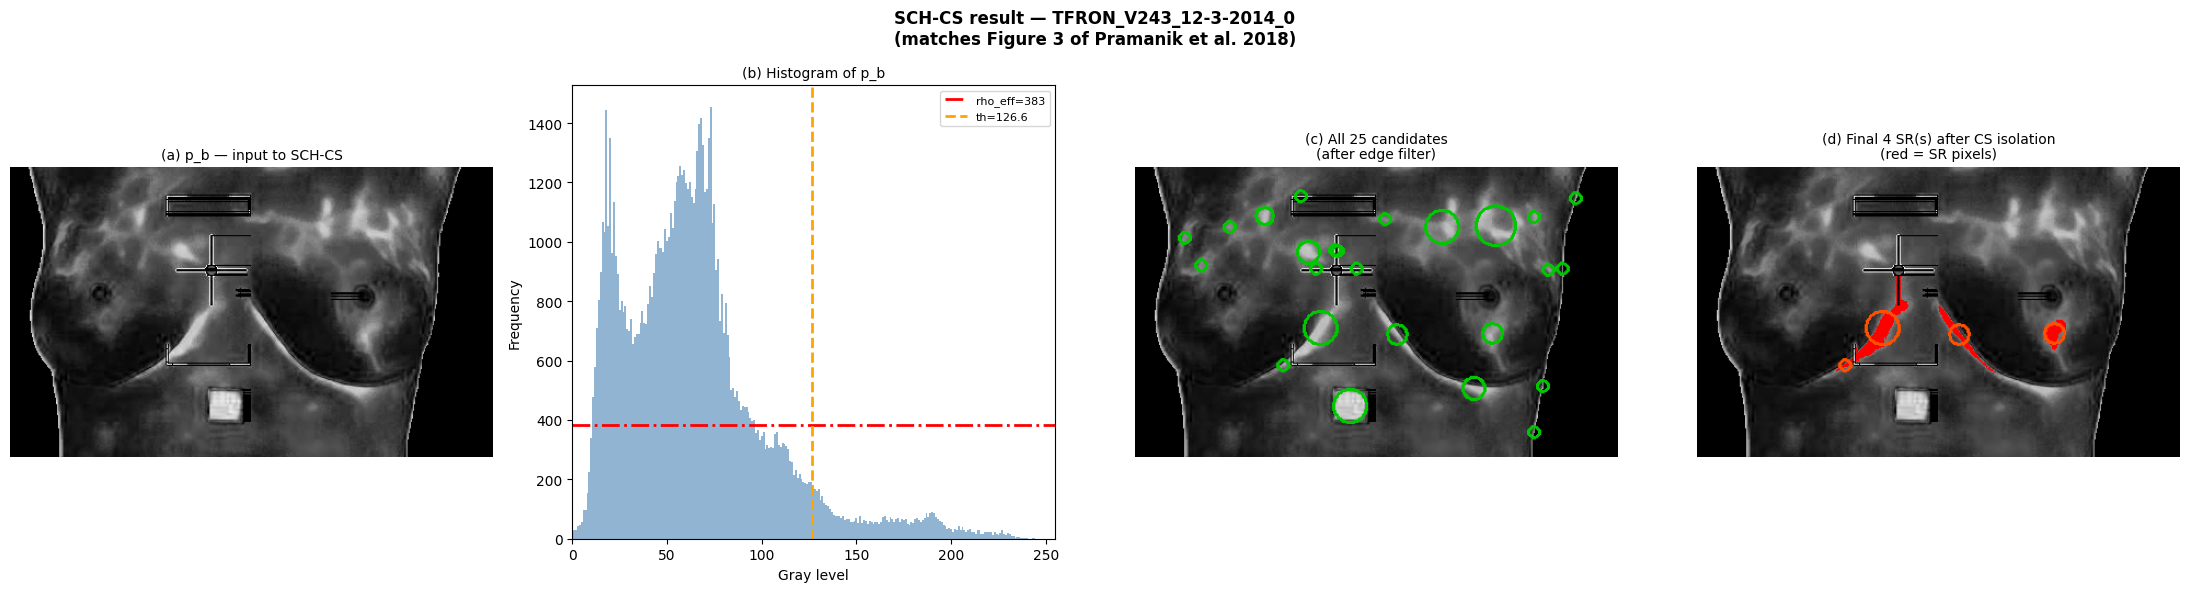


 Final SR summary:
  Label    Size(px)   Centroid(row,col)
  -------- ---------- --------------------
  53       750        (147.5, 168.7)
  55       294        (153.2, 239.2)
  58       280        (151.9, 326.4)
  68       48         (180.8, 135.2)

[Done] 4 SR(s) ready for DLPE Level Set.
[Save] Binary image saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260414_225709\TFRON_V243_12-3-2014_0_binary.png
[Save] SR mask saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260414_225709\TFRON_V243_12-3-2014_0_sr_mask.png
[Save] Labeled image saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260414_225709\TFRON_V243_12-3-2014_0_labeled.png
[Save] Regions data saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260414_225709\TFRON_V243_12-3-2014_0_regions.pkl
[Save] Metadata saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260414_225709\TFRON_V243_12-3-2014_0_metadata.json

Results saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260414_225709
Binary image (for Level Set) saved at: ..\data

In [10]:
schcs_result = run_schcs(
    pb=pb,
    cfg=SCH_CFG,
    visualize=True,
    image_name=image_name,
    save_results=True,
    storage_config=SchCsStorageConfig(output_dir=schcs_results_path)
)

# SCH-CS RESULTS
print(f"\nResults saved to: {schcs_result['run_dir']}")
print(f"Binary image (for Level Set) saved at: {schcs_result['saved_paths']['binary_image']}")

In [11]:
# GLOBAL DICTIONARY
schcs_runs = {}

# TRACKING DICTIONARY
schcs_runs[image_name] = {
    'run_dir': schcs_result['run_dir'],
    'timestamp': schcs_result['timestamp'],
    'num_regions': len(schcs_result['sr_regions'])
}

# SCH-CS RESULTS FOR LEVEL SET
schcs_results_loaded  = load_schcs_results(schcs_runs[image_name]['run_dir'])
p_th_b = schcs_results_loaded['binary_image']  # This is p_th_b for Eq 17
# GET N_SR FROM METADATA
n_sr = schcs_results_loaded['metadata']['num_sr_regions']

[Load] Binary image loaded: (265, 441)
[Load] SR mask loaded: (265, 441)
[Load] Regions data loaded
[Load] Loaded SCH-CS results for: TFRON_V243_12-3-2014_0
       Number of SR regions: 4


## STAGE 2: CHM Bias Correction

In [12]:
from src.utils import chm_corrected_results_path
from src.chm_bias_correction import CHMConfig, run_chm_pipeline


  CHM Bias Field Correction - Stage 2

[Step 0] Creating run folder...
[INFO] Outputs will be saved in: ..\data\chm_corrected\TFRON_V243_12-3-2014_0_20260414_225709
[Step 1] Computing CHM local...
[Step 2] Computing Nc...
[Step 3] Computing p_bar...
[Step 4] Saving all outputs...
[Step 5] Visualizing...


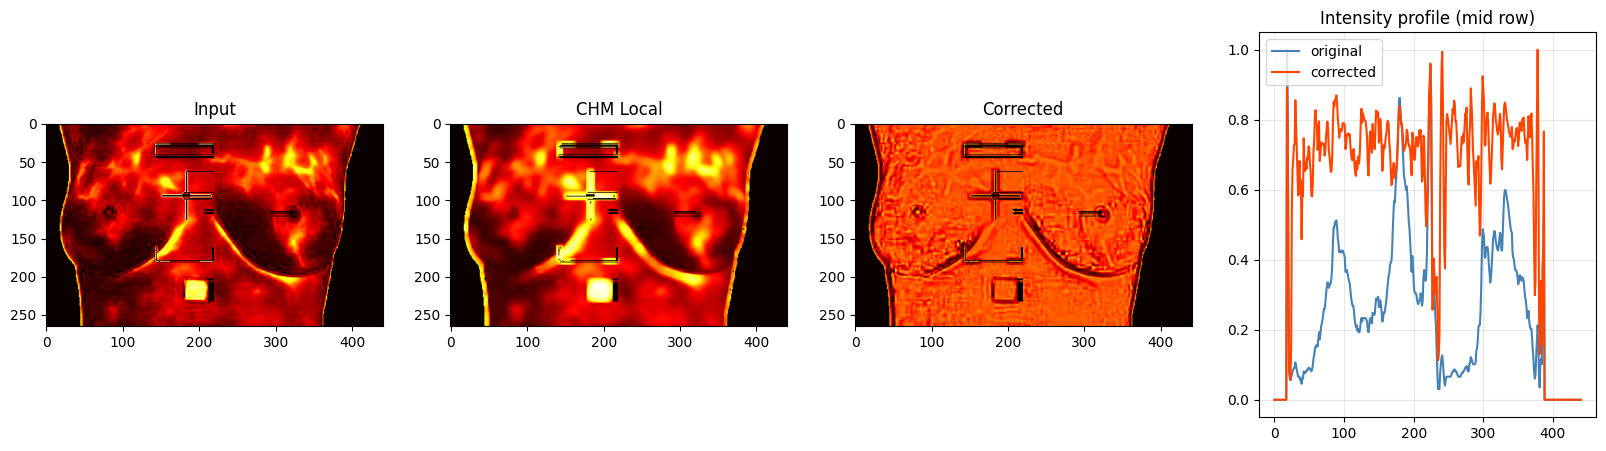

p_bar Saved here: ..\data\chm_corrected\TFRON_V243_12-3-2014_0_20260414_225709


In [13]:
section("CHM Bias Field Correction - Stage 2")

config = CHMConfig(
    save_visualization=True,
    show_visualization=True,
    output_dir=chm_corrected_results_path
)

chm_results = run_chm_pipeline(pb, config, image_name=image_name)

print("p_bar Saved here:", chm_results["run_dir"])

## STAGE 2: LEVEL SET INITIALIZATION

In [14]:
from src.utils import phi_initialized_result_path
from src.level_set_initialization import PhiInitConfig, run_phi_init_pipeline


  Level Set Function φ Initialization - Stage 2 Step 2


[φ Init] Processing: TFRON_V243_12-3-2014_0
  Preprocessed shape: (265, 441)
  SR regions count: 4

[Run Dir] ..\data\phi_initialized\TFRON_V243_12-3-2014_0_20260414_225711

[SR Mask] Building from validated SR regions:
  SR 53: 750px, centroid=(147.5, 168.7)
  SR 55: 294px, centroid=(153.2, 239.2)
  SR 58: 280px, centroid=(151.9, 326.4)
  SR 68: 48px, centroid=(180.8, 135.2)
  Total SR pixels: 1372 (1.17% of image)

[Eq 17] φ initialized:
  Shape: (265, 441)
  Inside (+4.0): 1372 px (1.17%)
  Outside (-4.0): 115493 px (98.83%)
  Unique values: [-4.  4.]

[Save] φ saved: ..\data\phi_initialized\TFRON_V243_12-3-2014_0_20260414_225711\phi_initial.npy


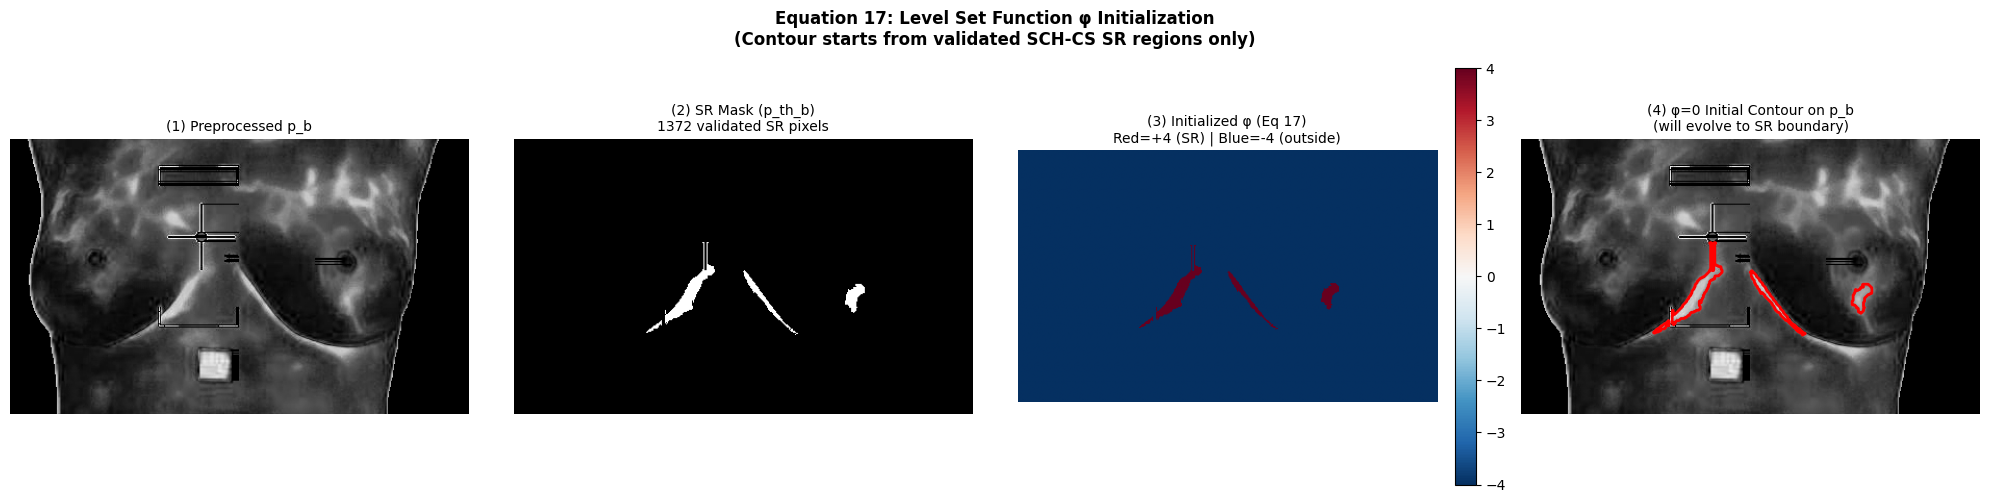


[Viz] Saved: ..\data\phi_initialized\TFRON_V243_12-3-2014_0_20260414_225711\phi_initialization.png

--- Verification ---
phi shape: (265, 441)
phi dtype: float64
phi values: [-4.  4.]   ← should be [-4. +4.]
Saved in: ..\data\phi_initialized\TFRON_V243_12-3-2014_0_20260414_225711


In [15]:
section("Level Set Function φ Initialization - Stage 2 Step 2")

# Configuration
config = PhiInitConfig(
    inside_value=4.0,
    outside_value=-4.0,
    save_visualization=True,
    show_visualization=True,
    save_phi_array=True,
    output_dir=phi_initialized_result_path
)

# Run pipeline
phi_init_results = run_phi_init_pipeline(
    preprocessed_image=preprocessing_results['pb'],
    sr_regions=schcs_result['sr_regions'],
    config=config,
    image_name=image_name
)

phi = phi_init_results["phi"]

print("\n--- Verification ---")
print(f"phi shape: {phi.shape}")
print(f"phi dtype: {phi.dtype}")
print(f"phi values: {np.unique(phi)}   ← should be [-4. +4.]")
print(f"Saved in: {phi_init_results['run_dir']}")

## STAGE 2: LEVEL SET ITERATION

In [16]:
from src.utils import level_set_iterated_results_path
from src.level_set_iteration import run_level_set, LevelSetConfig


  DLPE Level Set Iteration - Stage 2 Step 3


[Level Set] Processing: TFRON_V243_12-3-2014_0
  p_bar shape: (265, 441), dtype: float64
  phi_init shape: (265, 441), values: [-4.  4.]
  n_sr: 4

[Level Set] Initializing iteration loop
n_sr = 4 → ϑ = (0.1×255)/4 = 6.3750
α1=1.0, α2=1.0, θ=0.2
ε=1.5, dt=1.0, t_stop=0.05
max_iterations=500
------------------------------------------------------------
Iter    0 | l1=  0.370  l2=  0.357 | |1-r_prev|=1.0000  |1-r_curr|=1.0000
Iter    6 | l1=  0.369  l2=  0.358 | |1-r_prev|=0.0019  |1-r_curr|=0.0012
------------------------------------------------------------
[Stop] Criterion met at iteration 6.

[Done] Converged in 6 iterations.
Final l1 = 0.3686, l2 = 0.3576
SR pixels: 1191 (1.02% of image)

[Save] Results saved to: ..\data\level_set_iterated\TFRON_V243_12-3-2014_0_20260414_225713
[Viz] Saved: ..\data\level_set_iterated\TFRON_V243_12-3-2014_0_20260414_225713\TFRON_V243_12-3-2014_0_level_set_results.png


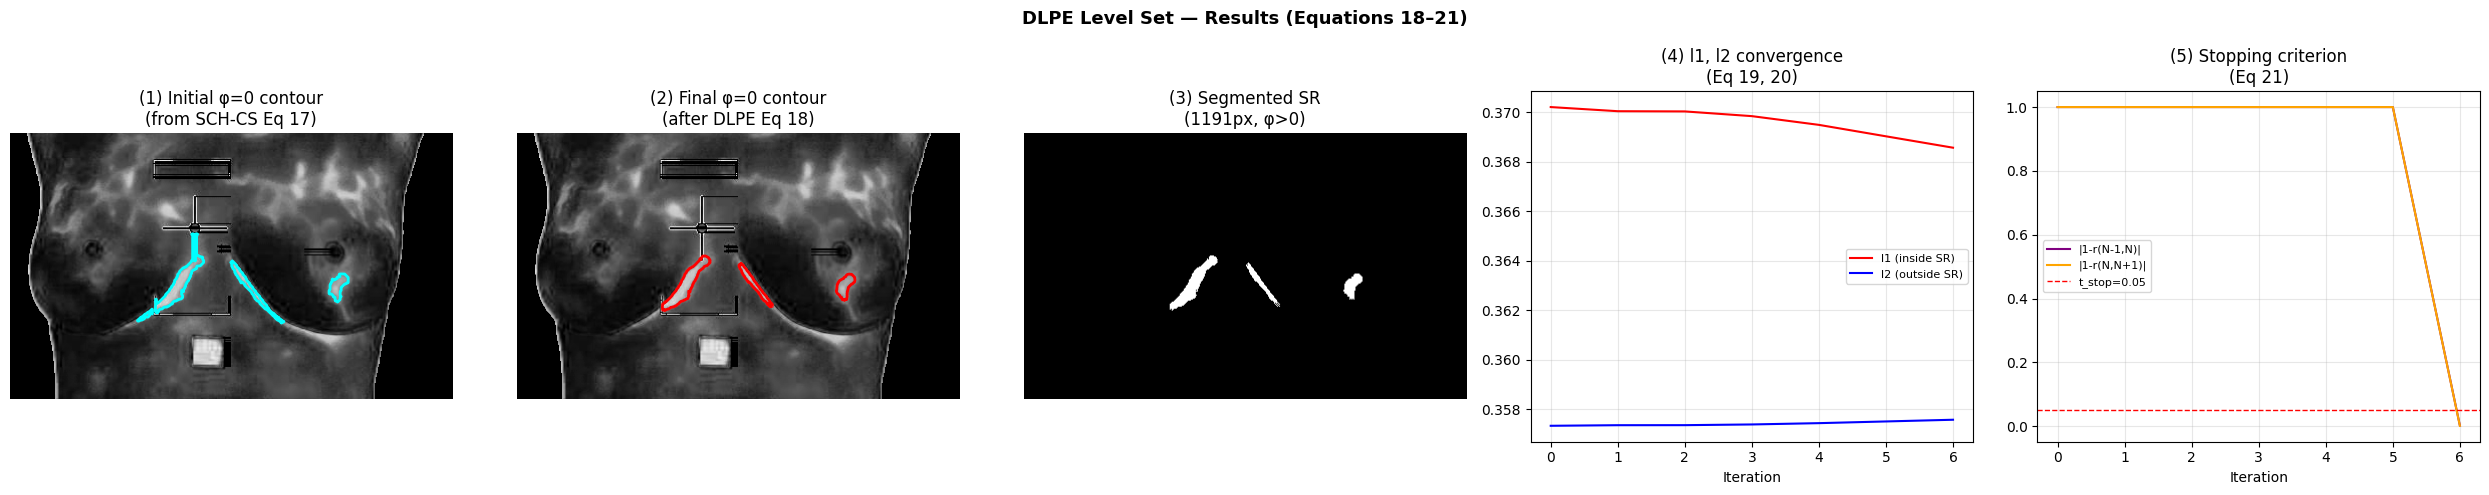


Results saved to: ..\data\level_set_iterated\TFRON_V243_12-3-2014_0_20260414_225713


In [17]:
section("DLPE Level Set Iteration - Stage 2 Step 3")
# Configuration
config = LevelSetConfig(
    alpha1=1.0,
    alpha2=1.0,
    theta=0.2,
    epsilon=1.5,
    dt=1.0,
    t_stop=0.05,
    max_iterations=500,
    verbose_every=50,
    output_dir=level_set_iterated_results_path
)

os.makedirs(config.output_dir, exist_ok=True)

# Run pipeline
level_set_iteration_results = run_level_set(
    p_bar=chm_results['p_bar'],
    phi_init=phi,
    n_sr=n_sr,
    image_name=image_name,
    preprocessed_img=pb,
    config=config,
    verbose=True,
    do_visualize=True,
    do_save=True
)

print(f"\nResults saved to: {level_set_iteration_results['run_dir']}")

## STAGE 3: SR SEGMENTATION

In [ ]:
from src.utils import segmentation_results_path
from src.sr_segmentation import SRSplitConfig, run_sr_split_pipeline

In [ ]:
section("SR Segmentation - Stage 3 Step 1")

config = SRSplitConfig(
    save_visualization=True,
    show_visualization=True,
    output_dir=segmentation_results_path
)

sr_split_results = run_sr_split_pipeline(
    preprocessed_img=pb,
    segmented_sr=level_set_iteration_results['segmented_sr'],
    config=config,
    image_name=image_name,
    # OPTIONAL
    centre_col_override=None
    # centre_col_override=200
)

print("Saved at:", sr_split_results["run_dir"])

## STAGE 3: FEATURE EXTRACTION

In [ ]:
from src.utils import extracted_features_results_path
from src.features_extraction import FeatureConfig, run_feature_pipeline

In [ ]:
section("Feature Extraction - Stage 3 Step 2")

config = FeatureConfig(
    output_dir=extracted_features_results_path,
    save_visualization=True,
    show_visualization=True
)

feature_extraction_results = run_feature_pipeline(
    preprocessed_img=pb,
    sr_left=sr_split_results['sr_left'],
    sr_right=sr_split_results['sr_right'],
    config=config,
    image_name=image_name
)

print("Saved at:", feature_extraction_results["run_dir"])

## STAGE 3: ASYMMETRIC FEATURE VECTOR

In [ ]:
from src.utils import asymmetric_vector_results_path
from src.asymmetry_vector import run_asymmetry_pipeline

In [ ]:
asymmetry_results = run_asymmetry_pipeline(
    f_v_left=feature_extraction_results['f_v_left'],
    f_v_right=feature_extraction_results['f_v_right'],
    image_name=image_name,
    base_output_dir=asymmetric_vector_results_path,
    label=f"Patient_{image_name}",
    save_visualization=True,
    show_visualization=True
)

F = asymmetry_results["F"]

print(f"\nF shape: {F.shape}")
print(f"Saved in: {asymmetry_results['run_dir']}")

## STAGE 3: FANN CLASSIFIER

In [ ]:
from src.fann_classifier import build_fann, compute_metrics, visualize_results, run_cross_validation

In [ ]:
section("FANN Classifier - Stage 3 Step 4")

# Load dataset
F_dataset = np.load("F_dataset.npy")
labels    = np.load("labels.npy")

results = run_fann_classification(
    F_dataset      = F_dataset,
    labels         = labels,
    base_output_dir= "fann_results",
    run_name       = "experiment1",
    save_output    = True
)

In [ ]:
 # Step 1: Load images
# left_img = cv2.imread("sr_left.png", cv2.IMREAD_GRAYSCALE)
# right_img = cv2.imread("sr_right.png", cv2.IMREAD_GRAYSCALE)

# Step 2: Extract asymmetry vector (21 features)
# from asymmetry_vector import compute_asymmetry_vector
# F_vector = compute_asymmetry_vector(left_img, right_img)  # shape (21,)

# Step 3: Pass F_vector to scaling step
F_scaled = scaler.transform(F.reshape(1, -1))  # shape (1,21)

# Step 4: Pass scaled features to prediction
pred_class = model.predict(F_scaled, verbose=0)[0]
pred_prob = model.predict_proba(F_scaled, verbose=0)[0, 1]

# Return all intermediate results
return {
    'features_raw': F_vector,
    'features_scaled': F_scaled,
    'prediction': pred_class,
    'probability': pred_prob
}

# Usage:
results = process_single_patient(
    "left.png", "right.png",
    scaler_final, final_model
)

# Access each step's output
print(f"Raw features: {results['features_raw']}")
print(f"Scaled features: {results['features_scaled']}")
print(f"Prediction: {results['prediction']}")

In [ ]:
# ── Load dataset ──────────────────────────────────────────────────────────
# F_dataset : shape (N, 21) — from asymmetry_vector.py
# labels    : shape (N,)    — 0=Normal, 1=Abnormal

# Option A: Load from .npy files (after processing all patients)
# F_dataset = np.load("F_dataset.npy")   # (155, 21) for paper's dataset
# labels    = np.load("labels.npy")       # (155,)

# Option B: Quick test with synthetic data to verify the pipeline works
# Replace this block with real data before dissertation submission
print("[Note]  Running with SYNTHETIC data to verify pipeline.")
print("        Replace with real F_dataset.npy and labels.npy.\n")
rng       = np.random.RandomState(42)
N_normal  = 81                              # 35+46 normal  (DMR-IR + DBT)
N_abnorm  = 74                              # 30+44 abnormal
N         = N_normal + N_abnorm

# Simulate: abnormal patients have higher asymmetry (larger F values)
F_normal  = rng.uniform(0.0, 0.3, (N_normal, 21))
F_abnorm  = rng.uniform(0.2, 0.8, (N_abnorm, 21))
F_dataset = np.vstack([F_normal, F_abnorm])
labels    = np.array([0]*N_normal + [1]*N_abnorm)

# ── Run 5-fold cross-validation ───────────────────────────────────────────
results = run_cross_validation(
    F_dataset = F_dataset,
    labels    = labels,
    n_splits  = 5
)

# ── Visualize ─────────────────────────────────────────────────────────────
visualize_results(results, save_path="classification_results.png")

# ── Save final model trained on ALL data (for deployment) ─────────────────
print("\n[Train] Training final model on full dataset...")
scaler_final = StandardScaler()
F_scaled     = scaler_final.fit_transform(F_dataset)
final_model  = build_fann()
final_model.fit(F_scaled, labels)
print("[Done]  Final model ready for inference.")
print("\n        To predict a new patient:")
print("          F_new     = compute_asymmetry_vector(f_left, f_right)")
print("          F_scaled  = scaler_final.transform(F_new.reshape(1,-1))")
print("          pred      = final_model.predict(F_scaled)")
print("          prob      = final_model.predict_proba(F_scaled)[:,1]")
print("          result    = 'Abnormal' if pred[0]==1 else 'Normal'")

## TESTING

In [ ]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter, gaussian_filter

def compute_p_bar_thermal(pb: np.ndarray,
                           window_size: int = 51,
                           order: int = 1) -> np.ndarray:
    """
    Fixed CHM correction specifically for thermal breast images.
    
    Two key changes from original:
        1. Window size increased from 9 → 51 (captures true slow-varying bias)
        2. Gaussian smoothing applied to CHM map before division
           (removes any remaining high-frequency artifacts)
    """
    p = pb.astype(np.float64)
    background_mask = (p == 0)

    # ── CHM with large window ─────────────────────────────────────────────────
    p_n1 = p ** (order + 1)      # p^2
    p_n  = p ** order            # p^1

    sum_n1 = uniform_filter(p_n1, size=window_size, mode='reflect') * window_size**2
    sum_n  = uniform_filter(p_n,  size=window_size, mode='reflect') * window_size**2

    epsilon = 1e-10
    sum_n   = np.where(sum_n < epsilon, epsilon, sum_n)
    chm_local = sum_n1 / sum_n

    # ── Smooth the CHM map (bias field must be smooth) ────────────────────────
    chm_smooth = gaussian_filter(chm_local, sigma=window_size/3)
    chm_smooth = np.where(chm_smooth < epsilon, epsilon, chm_smooth)

    # ── Nc over non-zero pixels only ──────────────────────────────────────────
    fg = ~background_mask
    Nc = np.sum(p[fg] ** (order+1)) / np.sum(p[fg] ** order)
    print(f"[Fixed] Nc = {Nc:.4f}")

    # ── p_bar = p * Nc / CHM_smooth ───────────────────────────────────────────
    p_bar = (p * Nc) / chm_smooth
    p_bar[background_mask] = 0.0

    # ── Contrast stretch foreground to [0, 255] ───────────────────────────────
    fg_vals = p_bar[fg]
    p_bar[fg] = (fg_vals - fg_vals.min()) / (fg_vals.max() - fg_vals.min()) * 255.0

    print(f"[Fixed] p_bar range: [{p_bar.min():.2f}, {p_bar.max():.2f}]")
    return p_bar


# ── Run it ────────────────────────────────────────────────────────────────────
p_bar_fixed = compute_p_bar_thermal(pb, window_size=51)

# ── Check contrast immediately ────────────────────────────────────────────────
from typing import Tuple
import matplotlib.pyplot as plt

def heaviside_smooth(phi: np.ndarray, epsilon: float) -> np.ndarray:
    return 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(phi / epsilon))
def update_region_means(p_bar: np.ndarray, phi: np.ndarray, epsilon: float) -> Tuple[float, float]:
    H = heaviside_smooth(phi, epsilon)

    numerator_l1 = np.sum(p_bar * H)
    denominator_l1 = np.sum(H)
    l1 = numerator_l1 / (denominator_l1 + 1e-10)

    one_minus_H = 1.0 - H
    numerator_l2 = np.sum(p_bar * one_minus_H)
    denominator_l2 = np.sum(one_minus_H)
    l2 = numerator_l2 / (denominator_l2 + 1e-10)

    return l1, l2
l1, l2 = update_region_means(p_bar_fixed, phi_init, epsilon=1.5)
print(f"l1         : {l1:.4f}")
print(f"l2         : {l2:.4f}")
print(f"|l1 - l2|  : {abs(l1-l2):.4f}   ← need > 20")

# ── Visual check ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(pb, cmap='hot')
axes[0].set_title("Original pb")
axes[0].axis('off')

axes[1].imshow(p_bar_fixed, cmap='hot')
axes[1].set_title("Fixed p_bar (window=51, smoothed CHM)\n"
                  "Breast hot spots should be clearly brighter")
axes[1].axis('off')

axes[2].imshow(p_bar_fixed, cmap='hot')
axes[2].contour(phi_init, levels=[0], colors=['cyan'], linewidths=[2])
axes[2].set_title(f"Fixed p_bar + initial contour\n"
                  f"|l1-l2| = {abs(l1-l2):.2f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
section("DLPE Level Set Iteration - Stage 2 Step 3")

config = LevelSetConfig(dt=0.01, t_stop=0.001, output_dir=level_set_iterated_results_path)
os.makedirs(config.output_dir, exist_ok=True)

level_set_iteration_results = run_level_set(
    # p_bar=chm_results['p_bar'],
    p_bar=p_bar_fixed,
    phi_init=phi_init,
    n_sr=n_sr,
    image_name=image_name,
    preprocessed_img=pb,
    config=config,
    verbose=True,
    do_visualize=True,
    do_save=True
)

print(f"\nResults saved to: {level_set_iteration_results['run_dir']}")

if 'segmented_sr' in level_set_iteration_results['saved_paths']:
    print(f"Segmented SR saved to: {level_set_iteration_results['saved_paths']['segmented_sr']}")